
<h1 style="color: #ffffff;"><center> Trinidad & Tobago's Crime Data Exploration - Part 1: <br>Reported Murders</center></h1>

Kevin Folkes <br>
2024-06-24

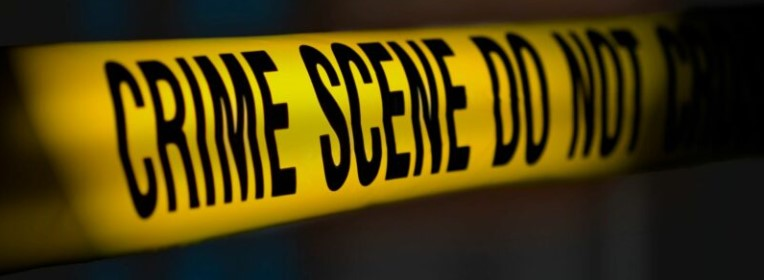 |
-


### Project Outline: 


- Locate and select data from the TTPS site, using Selenium Automation.
- Srape/import data into notebook.
- Clean and prepare the data suitable for use. 
- Train 80% of the data to a ML model then test conferdence interval.
- predict the coming months.

---



In [1]:
# import libraries needed: 

## Forecasting
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.theta import ThetaForecaster
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.utils.plotting import plot_series
import prophet
# Prophet
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# Automation
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.action_chains import ActionChains

# Web Scraping
from bs4 import BeautifulSoup

# Pandas
import pandas as pd
import numpy as np

# Ploting
import matplotlib.pyplot as plt
import seaborn as sns


### Selenium Automation

- Locate and select data from the TTPS site, using Selenium Automation.
----

In [2]:
# setup the webDriver: 
driver = webdriver.Chrome()

# Open the Webpage: 
url = 'https://www.ttps.gov.tt/Stats/Crime-Totals-By-Month'
driver.get(url)

# wait for the page to load: 
time.sleep(2)

In [3]:
    # locate and select the offence dropdown:
offence_dropdown = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox2_B-1')
ActionChains(driver).move_to_element(offence_dropdown).click(offence_dropdown).perform()

# wait for the page to load: 
time.sleep(1)

# from the dropdown, select the offence desired: 
murder_offence = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox2_DDD_L_LBI8T0')
ActionChains(driver).move_to_element(murder_offence).click(murder_offence).perform()

# wait for the page to load: 
time.sleep(1)

# Locate and select the table tab to display tabular data: 
table = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxPageControl1_T1T')
ActionChains(driver).move_to_element(table).click(table).perform()

# wait for the page to load: 
time.sleep(2)

In [5]:
# Get a list of all year Id's in the year dropdown: 
# find the container where the year dropdown data is stored: 
container = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBT')

# get all the td elements in the container: 
td_elements = container.find_elements(By.TAG_NAME, 'td')

# extract the id's from the td tag:
year_ids = [td.get_attribute('id') for td in td_elements if td.get_attribute('id')]

# print all the id's collected: 
for year_id in year_ids: 
    print(year_id)

dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI0T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI1T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI2T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI3T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI4T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI5T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI6T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI7T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI8T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI9T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI10T0
dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_DDD_L_LBI11T0


### Selenium Automation & Web Scraping: 

- Here, we're combining the automation and web scraping to store the tabular data in a list.
- Selenium will navigate the page, then Beautiful Soup will parse the page and bring in the data.
----


In [6]:
# create an empty list to store the data in: 
table_info = []


# loop through each year in the dropdown year, generate the report then web scrap the table info.
# store the table info in the empty list created above

for report_year in year_ids: 
    
    # find the year dropdown: 
    year_dropdown = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxComboBox3_I')
    # select dropdown: 
    ActionChains(driver).move_to_element(year_dropdown).click(year_dropdown).perform()
    # Wait for the page to load
    time.sleep(2)
    
    # Get the year in the dropdown: 
    year_select = driver.find_element(By.ID, report_year)
    # Extract the year text: 
    year = year_select.text
    #select the year: 
    ActionChains(driver).move_to_element(year_select).click(year_select).perform()
    # Wait for the page to load
    time.sleep(2)
    
    # find the generate report button: 
    generate = driver.find_element(By.ID, 'dnn_ctr453_TTPSCrimeMonthTotals_ASPxRoundPanel1_ASPxButton1_CD')
    # select generate report: 
    ActionChains(driver).move_to_element(generate).click(generate).perform()
    time.sleep(3)
    
    
    
    
    # Here we are swtitching to web scraping with Beautiful Soup: 
    
    
    
    # get the page source: 
    page_source = driver.page_source
    # parse with bs4
    soup = BeautifulSoup(page_source, 'html.parser')
    
    # get the table location: 
    page_table = soup.find('table', id='dnn_ctr453_TTPSCrimeMonthTotals_ASPxPageControl1_ASPxGridView1_DXMainTable')
    # there is no tagged table headers so we will skip this step and create our own headers later.
    
    # get the table rows: 
    rows = page_table.find_all('tr')#[3:-1]  Here you can skip rows if needed, but we will keep all rows and clean later in the data cleaning section.
    
    # loop through all the rows and extract the info then store them in the empty list we created
    for row in rows: 
        cells = row.find_all('td')
        #strip the text in each cell of any whitespace.
        cell_data = [cell.text.strip() for cell in cells]
        #add the year in which this info was taken
        cell_data.append(year)
        # Add the data to the empty list: 
        table_info.append(cell_data)
    
    
    # print the year when the data is finished extracting and stored: 
    print(f'All data in {year}, has been extracted and stored in the list: table_info')
    

All data in 2013, has been extracted and stored in the list: table_info
All data in 2014, has been extracted and stored in the list: table_info
All data in 2015, has been extracted and stored in the list: table_info
All data in 2016, has been extracted and stored in the list: table_info
All data in 2017, has been extracted and stored in the list: table_info
All data in 2018, has been extracted and stored in the list: table_info
All data in 2019, has been extracted and stored in the list: table_info
All data in 2020, has been extracted and stored in the list: table_info
All data in 2021, has been extracted and stored in the list: table_info
All data in 2022, has been extracted and stored in the list: table_info
All data in 2023, has been extracted and stored in the list: table_info
All data in 2024, has been extracted and stored in the list: table_info


In [7]:
driver.close()

### Data Cleaning & Preparation: 
- Data will be stored in a df then cleaned and standardize.
---


In [8]:
# transfer the collected table info to a dataframe: 
crime_df = pd.DataFrame(table_info)

crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       188 non-null    object
 1   1       188 non-null    object
 2   2       164 non-null    object
 3   3       12 non-null     object
 4   4       12 non-null     object
dtypes: object(5)
memory usage: 7.5+ KB


In [9]:
crime_df.head()

,0,1,2,3,4
0,Month,Month,Total,Total,2013
1,Month,2013,None,None,None
2,Total,2013,None,None,None
3,Jan,38,2013,None,None
4,Feb,46,2013,None,None


In [10]:
# We can see that there are 2 unnecessary columns, they will be removed.
# column names will be changed. 
# df will be cleaned by removeing all None, Month & Sum entries

# remove unwanted columsn: 
crime_df = crime_df[[2, 0, 1, ]]

# rename columsn: 
crime_df.rename(columns={0: 'Month', 1: 'Total', 2: 'Year'}, inplace=True)


#Filter the df to only show data needed (remove rows with 'Total, Month & None')
crime_df = crime_df[crime_df['Month'] != 'Month']
crime_df = crime_df[crime_df['Month'] != 'Total']
crime_df = crime_df[~crime_df['Total'].str.contains('Sum')]

# reset index and drop extra column.
crime_df.reset_index(drop=True, inplace=True)

# the last two months appear to have no date, we'll remove them since it would create outliers
crime_df = crime_df.iloc[: -1]

In [11]:
crime_df.tail()

,Year,Month,Total
134,2024,Mar,57
135,2024,Apr,37
136,2024,May,53
137,2024,Jun,51
138,2024,Jul,66


In [12]:
# Having the year and the Month in separate columns and in differemt formats isnt helpful.

# create a mapping for months: 
month_map = {
    'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Aug': '08',
    'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

# Add month numnbers to df    
crime_df['Month_Num'] = crime_df['Month'].map(month_map)  
# combine month number and year to df as a pandas datetime object.
crime_df['date'] = pd.to_datetime(crime_df['Month_Num'].astype(str) + crime_df['Year'])
#format the month_year column
crime_df['Month_Year'] = crime_df['date'].dt.strftime('%m-%Y')

# Create a copy of the df for the Prophet Forecasting (we will use 2 type of models)
crime_df_fb = crime_df.copy()


#apply the month_year as the index 
crime_df.index = crime_df['Month_Year']

# drop all other columns except totals: 
crime_df = crime_df[[ 'Total']]

# change the index to a period type with a monthly frequency: 
crime_df.index = pd.PeriodIndex(crime_df.index, freq='M')

# change the total to int type.
crime_df['Total'] = crime_df['Total'].astype(int)

crime_df.head()

C:\Users\Jessiah\AppData\Local\Temp\ipykernel_16200\1912704456.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df['date'] = pd.to_datetime(crime_df['Month_Num'].astype(str) + crime_df['Year'])


,Total
Month_Year,
2013-01,38
2013-02,46
2013-03,18
2013-04,19
2013-05,33


### Forecasting
- Split and train the model on 80% of the data, then cross validate with 20% test data.
- Predict the follwing months.
- Calculate the Mean Absolute Percentage Error
- Plot findings
---

#### Tetha Model:

In [13]:
crime_df_cleaned = crime_df.copy()

# split the df into 80/20 for training and testing: 

crime_df_cleaned_train, crime_df_cleaned_test = temporal_train_test_split(crime_df_cleaned, train_size=0.8)

# set the forecast horizon: 
fh = ForecastingHorizon(crime_df_cleaned_test.index, is_relative=False)
#fh = ForecastingHorizon([i for i in range(1,12)])

# use the Theta Forcaster model and set the seasonal period to 12 (yearly)
forecaster = ThetaForecaster(sp=12)

# Train the model on the data
forecaster.fit(crime_df_cleaned_train)

# Predict the 20% test data
crime_pred = forecaster.predict(fh)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Total'>)

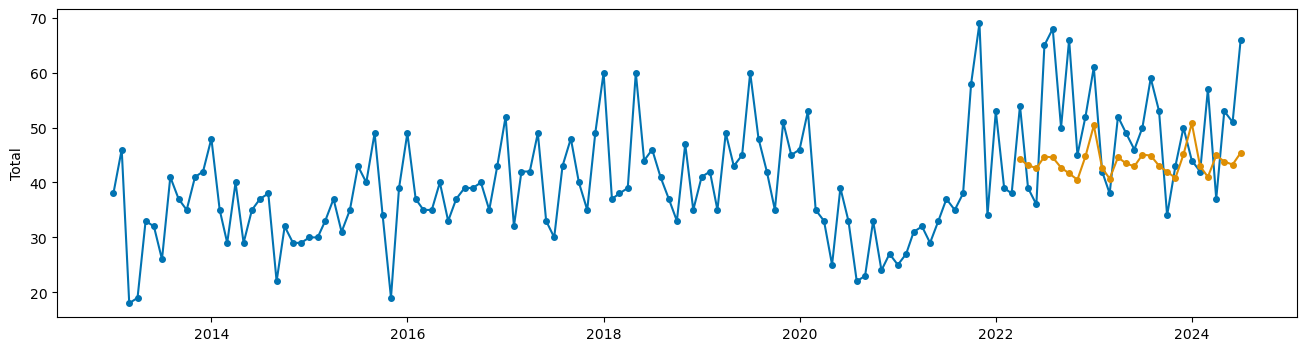

In [14]:
# plot the trained data against the test data:
plot_series(crime_df_cleaned, crime_pred)

In [15]:
#get the Mean percentage error: 
meap = mean_absolute_percentage_error(crime_df_cleaned_test, crime_pred)

print(f'Mean Absolute Percentage Error: {round(meap*100, 2)}%')

Mean Absolute Percentage Error: 16.71%


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Total'>)

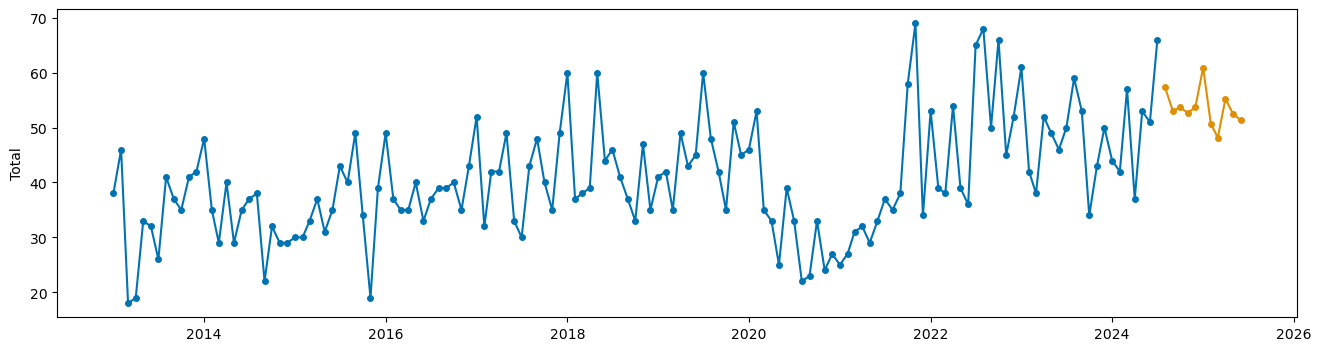

In [16]:
# Forcast into the future: 
forecaster = ThetaForecaster(sp=12)
fh = ForecastingHorizon([i for i in range(1,12)])

# Train the model on all of the data
forecaster.fit(crime_df_cleaned)

# Predict the future data
crime_pred = forecaster.predict(fh)

# plot the trained data against the test data:
plot_series(crime_df_cleaned, crime_pred)

----
## Prophet Model:

In [17]:
# Remove unwanted columns: 
crime_df_fb =  crime_df_fb[['Month_Year', 'Total']]

# change Month_Year column to datetime
crime_df_fb['Month_Year'] = pd.to_datetime(crime_df_fb['Month_Year'])
# change Total column to integer
crime_df_fb['Total'] = crime_df_fb['Total'].astype(int)

# Rename columns: 
crime_df_fb.rename(columns= {'Month_Year' : 'ds', 'Total': 'y'}, inplace=True)

crime_df_fb['ds'] = crime_df_fb['ds'] + pd.offsets.MonthEnd(0)
crime_df_fb.head()

C:\Users\Jessiah\AppData\Local\Temp\ipykernel_16200\930074799.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df_fb['Month_Year'] = pd.to_datetime(crime_df_fb['Month_Year'])


,ds,y
0,2013-01-31,38
1,2013-02-28,46
2,2013-03-31,18
3,2013-04-30,19
4,2013-05-31,33


In [19]:
train_df = crime_df_fb[(crime_df_fb['ds'] < '2024-02-29')]

In [20]:
lockdowns = pd.DataFrame([
    {'holiday': 'lockdown_1', 'ds': '2020-03-31', 'lower_window': 0, 'ds_upper': '2021-09-30'},

])
for t_col in ['ds', 'ds_upper']:
    lockdowns[t_col] = pd.to_datetime(lockdowns[t_col])
lockdowns['upper_window'] = (lockdowns['ds_upper'] - lockdowns['ds']).dt.days
lockdowns

,holiday,ds,lower_window,ds_upper,upper_window
0,lockdown_1,2020-03-31,0,2021-09-30,548


In [109]:
lockdowns2 = pd.DataFrame([
    {'holiday': 'lockdown_1', 'ds': '2021-03-01', 'lower_window': 0, 'ds_upper': '2021-09-30'},

])
for t_col in ['ds', 'ds_upper']:
    lockdowns2[t_col] = pd.to_datetime(lockdowns2[t_col])
lockdowns2['upper_window'] = (lockdowns2['ds_upper'] - lockdowns2['ds']).dt.days
lockdowns2

,holiday,ds,lower_window,ds_upper,upper_window
0,lockdown_1,2020-03-01,0,2021-09-30,578


In [110]:
train_df.reset_index(drop=True, inplace=True)
train_df

,ds,y
0,2013-01-31,38
1,2013-02-28,46
2,2013-03-31,18
3,2013-04-30,19
4,2013-05-31,33
...,...,...
128,2023-09-30,53
129,2023-10-31,34
130,2023-11-30,43
131,2023-12-31,50


In [111]:
crime_df_fb

,ds,y
0,2013-01-31,38
1,2013-02-28,46
2,2013-03-31,18
3,2013-04-30,19
4,2013-05-31,33
...,...,...
134,2024-03-31,57
135,2024-04-30,37
136,2024-05-31,53
137,2024-06-30,51


In [133]:
# Post Covid test
post_covid = crime_df_fb[crime_df_fb['ds'] >= '2021-10-01']
post_covid.reset_index(inplace=True, drop = True)

post_covid = post_covid.head(32)
post_covid.tail()

In [149]:
# set the model seasonality
m = Prophet( holidays=lockdowns, seasonality_mode='multiplicative', changepoint_prior_scale=0.05, changepoint_range=0.95)
m2 = Prophet(seasonality_mode='multiplicative')

# train the model on the data
m.fit(train_df)
m2.fit(post_covid)

# set the predicted dates amount
future = m.make_future_dataframe( periods=12, freq='M')
future2 = m2.make_future_dataframe( periods=12, freq='M')

future.tail()

19:24:29 - cmdstanpy - INFO - Chain [1] start processing
19:24:29 - cmdstanpy - INFO - Chain [1] done processing
19:24:29 - cmdstanpy - INFO - Chain [1] start processing
19:24:29 - cmdstanpy - INFO - Chain [1] done processing


,ds
140,2024-09-30
141,2024-10-31
142,2024-11-30
143,2024-12-31
144,2025-01-31


In [151]:
# predict the next 12 months: 
forecast = m.predict(future)
forecast2 = m2.predict(future2)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
140,2024-09-30,53.231176,43.756019,61.536139
141,2024-10-31,52.511738,43.656076,61.018624
142,2024-11-30,52.318738,43.142834,61.235633
143,2024-12-31,50.817020,41.351339,59.522824
144,2025-01-31,59.952714,50.934707,68.603609


In [152]:
# add residuals calumns
forecast['residuals'] = crime_df_fb['y'] - forecast['yhat']
forecast2['residuals'] = post_covid['y'] - forecast2['yhat']
# calulate ape
forecast['absolute_percentage_error'] = abs(forecast['residuals'] / crime_df_fb['y']) * 100
forecast2['absolute_percentage_error'] = abs(forecast2['residuals'] / post_covid['y']) * 100
# calcualte mape
mape = forecast['absolute_percentage_error'].mean()
mape2 = forecast2['absolute_percentage_error'].mean()
mape

12.889476522766868

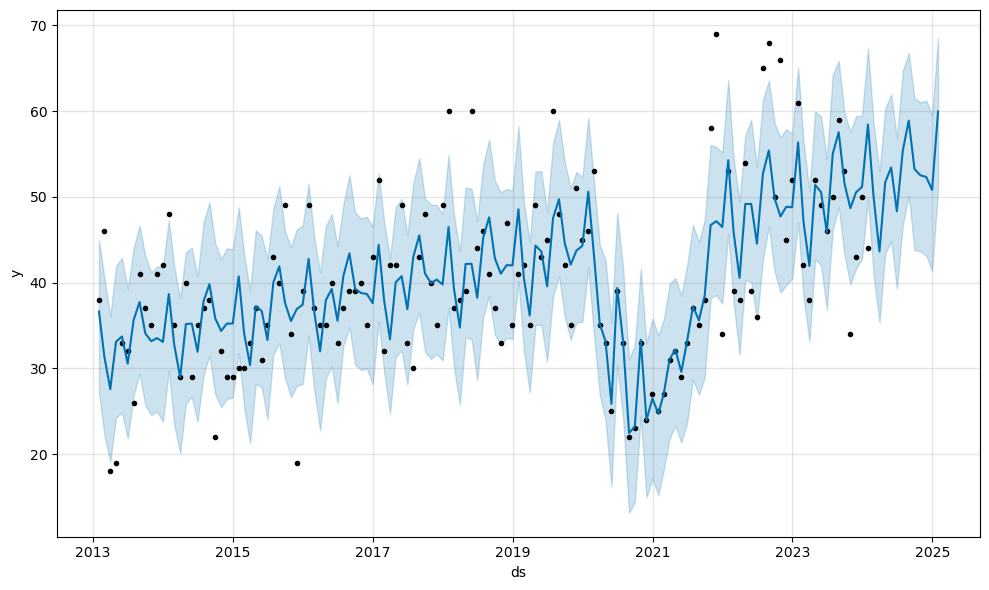

In [155]:
# plot forecast
fig1 = m.plot(forecast)

C:\Users\Jessiah\anaconda3\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\Jessiah\anaconda3\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\Jessiah\anaconda3\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



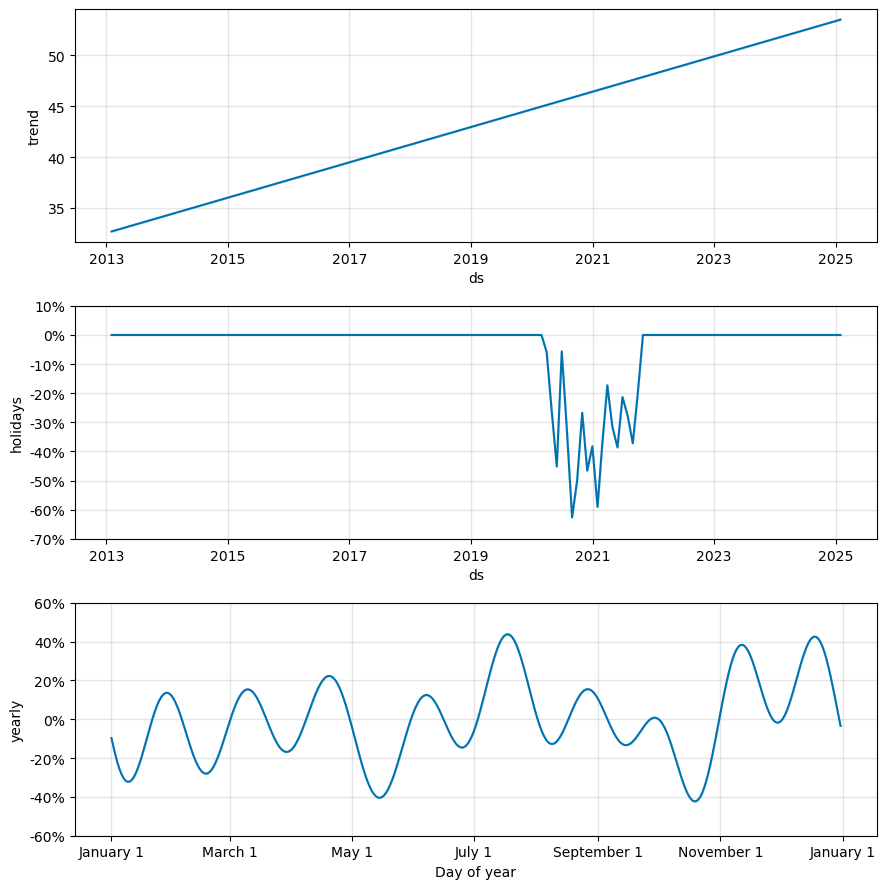

In [156]:
# plot components
fig2 = m.plot_components(forecast)

C:\Users\Jessiah\anaconda3\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\Jessiah\anaconda3\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



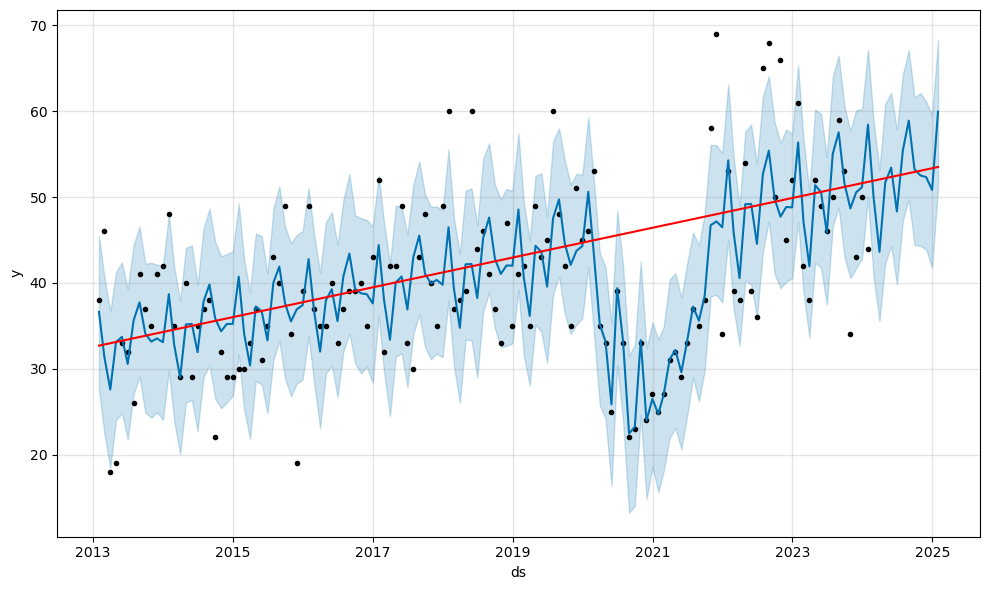

In [148]:
# Python
from prophet.plot import add_changepoints_to_plot
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)


C:\Users\Jessiah\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



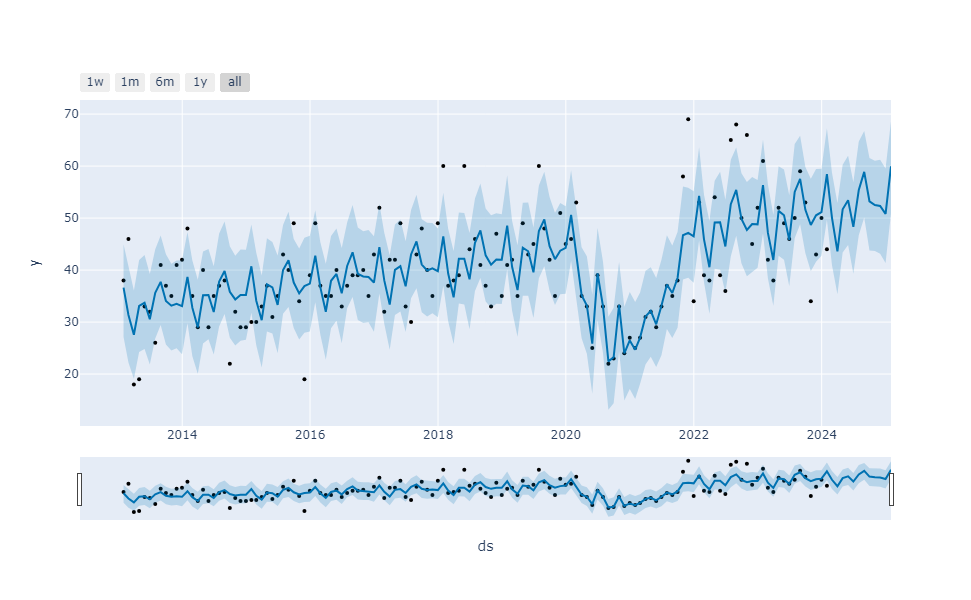

In [157]:
# interactive plot
plot_plotly(m, forecast)

In [158]:
print(f'Mean Absolute Percentage Error: {round(mape, 2)}%')

Mean Absolute Percentage Error: 12.89%


### Next Steps: 

- Identify and Remove outliers from data.
- Add regressor for Covid19 period.
- Cross Validate data and find tune metrics
- Lower meap value to be more accurate with the predictions.